# SQD Problem Set: H₂O Symmetric O–H Stretch

This notebook is a **problem-set** companion to the [SQD tutorial notebook](https://quantum.cloud.ibm.com/docs/en/tutorials/sample-based-quantum-diagonalization).

In this problem set, you will adapt the same workflow to a small **potential-energy curve** problem: the symmetric O–H stretch of water with the following geometry:

$$
R_{\mathrm{OH}} \in \{R_1, R_2, \ldots\},
\qquad
\theta = \angle \mathrm{HOH} = 104.5^\circ
$$
$$
\mathrm{O}=(0,0,0), \qquad
\mathrm{H}_\pm = \left(\pm R\sin
\frac{\theta}{2}, 0, R\cos
\frac{\theta}{2}
\right).
$$

The SQD workflow is as follows:

1. Build molecular integrals with PySCF.
2. Define a small active space.
3. Construct an LUCJ ansatz from CCSD amplitudes.
4. Generate bitstring samples.
5. Post-process samples with SQD.
6. Compare SQD energies along a bond-stretch coordinate.

In [1]:
import math
import warnings
from functools import partial

import ffsim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyscf
import pyscf.ao2mo
import pyscf.cc
import pyscf.gto
import pyscf.mcscf
import pyscf.scf
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from qiskit_addon_sqd.fermion import (
    SCIResult,
    diagonalize_fermionic_hamiltonian,
    solve_sci_batch,
)

from utils_v5 import (
    make_heavy_hex_grid,
    make_square_grid,
    plot_coupling_map,
    lucj_ab_pair_paths_dataframe,
    plot_lucj_mapping_from_result,
)

warnings.filterwarnings("ignore")


## Helper functions


In [2]:
def h2o_symmetric_stretch_geometry(r_oh: float, angle_deg: float = 104.5):
    """Return a PySCF-compatible H2O geometry for symmetric O-H stretch."""
    theta = math.radians(angle_deg)
    x = r_oh * math.sin(theta / 2)
    z = r_oh * math.cos(theta / 2)
    return [
        ["O", (0.0, 0.0, 0.0)],
        ["H", ( x, 0.0, z)],
        ["H", (-x, 0.0, z)],
    ]


def plot_h2o_geometry(atom, title="H2O geometry"):
    """Simple 2D plot of the x-z projection of an H2O geometry."""
    labels = [a[0] for a in atom]
    coords = np.array([a[1] for a in atom], dtype=float)
    x = coords[:, 0]
    z = coords[:, 2]

    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    ax.plot([x[0], x[1]], [z[0], z[1]], linewidth=2)
    ax.plot([x[0], x[2]], [z[0], z[2]], linewidth=2)
    ax.scatter(x, z, s=[180 if label == "O" else 90 for label in labels])
    for label, xi, zi in zip(labels, x, z):
        ax.annotate(
            label,
            xy=(xi, zi),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
        )
    ax.set_aspect("equal")
    ax.set_xlabel("x [Angstrom]")
    ax.set_ylabel("z [Angstrom]")
    ax.margins(x=0.25, y=0.35)
    ax.set_title(title, pad=18)
    plt.tight_layout()
    plt.show()

### Base geometry check

Before doing electronic-structure calculations, confirm that the symmetric stretch geometry behaves as expected.

[['O', (0.0, 0.0, 0.0)], ['H', (0.7574806116466019, 0.0, 0.5865041542730024)], ['H', (-0.7574806116466019, 0.0, 0.5865041542730024)]]


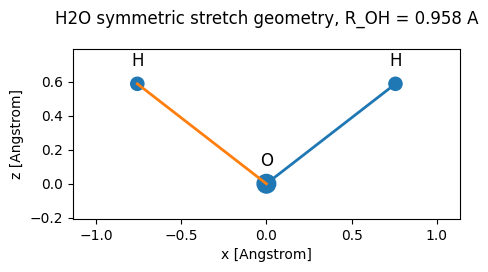

In [3]:
# Equilibrium-like water geometry for debugging.
r_eq = 0.958
angle_deg = 104.5
atom_eq = h2o_symmetric_stretch_geometry(r_eq, angle_deg=angle_deg)

print(atom_eq)
plot_h2o_geometry(atom_eq, title=f"H2O symmetric stretch geometry, R_OH = {r_eq:.3f} A")

## Problems

Complete the following problems by referring to the SQD tutorial notebook; they mirror the [web tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/sample-based-quantum-diagonalization).

- **Problem 1** corresponds to tutorial **Step 1: Map classical inputs to a quantum problem**.
- **Problem 2** corresponds to the tutorial's **LUCJ ansatz construction** and **Step 2: Optimize for hardware execution**.
- **Problem 3** corresponds to tutorial **Step 3: Execute using Qiskit primitives** and the first part of **Step 4**.
- **Problem 4** corresponds to tutorial **Step 4: Post-process with SQD**.
- **Problem 5** combines the previous steps into a small H₂O stretch study.

### Problem 1. Build an H₂O active-space Hamiltonian along a symmetric stretch

**Goal.** Convert each H₂O geometry into an active-space electronic-structure Hamiltonian.

Use the tutorial's **Step 1** as the template. Replace the N₂ geometry by the H₂O symmetric stretch geometry above.

**What you should do**

1. Build a PySCF molecule for a given `r_oh`.
2. Run RHF.
3. Freeze the lowest orbital, which approximately corresponds to the oxygen 1s core orbital in a minimal basis.
4. Define the active space from the remaining orbitals.
5. Compute
   - `hcore`,
   - `eri`,
   - `nuclear_repulsion_energy`,
   - `norb`,
   - `nelec`,
   - active-space reference energy from CASCI/FCI.
6. Run frozen-core CCSD and store `t1`, `t2` for LUCJ initialization.

**Deliverables**

- A function `build_h2o_active_space_case`.
- A table of active-space metadata for several O–H distances.
- A reference PES plot from the active-space exact/CASCI energy.

**Suggested workshop settings**

Use `basis="6-31G"`, `n_frozen=1`, and a small grid such as `np.linspace(0.80, 1.60, 5)`.

In [4]:
def build_h2o_active_space_case(
    r_oh: float,
    *,
    angle_deg: float = 104.5,
    basis: str = "6-31G",
    n_core_frozen: int = 0,
    verbose: int = 0,
):
    """Build active-space data for one H2O symmetric-stretch geometry.

    Refer to tutorial Step 1.
    """
    atom = h2o_symmetric_stretch_geometry(r_oh, angle_deg=angle_deg)

    mol = pyscf.gto.Mole()
    mol.build(
        atom=atom,
        basis=basis,
        charge=0,
        spin=0,
        symmetry=False,
        verbose=verbose,
    )

    # 1a: run RHF.
    scf = pyscf.scf.RHF(mol).run()

    # 1b: define active_space by freezing the first `n_frozen` orbitals.
    n_mo = scf.mo_coeff.shape[1]
    active_orbitals = list(range(
        n_core_frozen,
        n_mo,
    ))
    active_space = active_orbitals

    # 1c: compute norb, n_electrons, n_alpha, n_beta, and nelec.
    norb = len(active_orbitals)
    n_electrons = int(round(np.sum(scf.mo_occ[active_orbitals])))
    n_alpha = (n_electrons + mol.spin) // 2
    n_beta = (n_electrons - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    # 1d: build CASCI and extract active-space integrals.
    cas = pyscf.mcscf.CASCI(scf, norb, nelec)
    mo = cas.sort_mo(active_orbitals, base=0)
    hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
    eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

    # 1e: compute the active-space exact/CASCI reference energy.
    reference_energy = cas.run().e_tot

    # 1f: run frozen-core CCSD and store t1, t2 for LUCJ.
    frozen = [i for i in range(mol.nao_nr()) if i not in active_orbitals]
    ccsd = pyscf.cc.CCSD(scf, frozen=frozen).run()
    t1 = ccsd.t1
    t2 = ccsd.t2

    return {
        "r_oh": r_oh,
        "angle_deg": angle_deg,
        "basis": basis,
        "n_core_frozen": n_core_frozen,
        "atom": atom,
        "mol": mol,
        "scf": scf,
        "active_space": active_space,
        "norb": norb,
        "nelec": nelec,
        "n_alpha": n_alpha,
        "n_beta": n_beta,
        "hcore": hcore,
        "eri": eri,
        "nuclear_repulsion_energy": nuclear_repulsion_energy,
        "reference_energy": reference_energy,
        "ccsd": ccsd,
        "ccsd_energy": ccsd.e_tot,
        "t1": t1,
        "t2": t2,
    }

In [ ]:
# Build a small stretch grid.
r_values = np.linspace(0.80, 1.60, 5)

# 1g: build a list of cases for all r_values.
h2o_cases = [
    build_h2o_active_space_case(r_oh, basis="6-31G", n_core_frozen=1)
    for r_oh in r_values
]

# 1h: summarize the active-space data in a pandas DataFrame.
summary_rows = []
for case in h2o_cases:
    summary_rows.append(
        {
            "R_OH [A]": case["r_oh"],
            "basis": case["basis"],
            "norb": case["norb"],
            "nelec": case["nelec"],
            "qubits": 2 * case["norb"],
            "CASCI energy [Ha]": case["reference_energy"],
            "CCSD energy [Ha]": case["ccsd_energy"],
        }
    )

h2o_summary_df = pd.DataFrame(summary_rows)
display(h2o_summary_df)

,R_OH [A],basis,norb,nelec,qubits,CASCI energy [Ha],CCSD energy [Ha]
0,0.8,6-31G,12,"(4, 4)",24,-76.033512,-76.032523


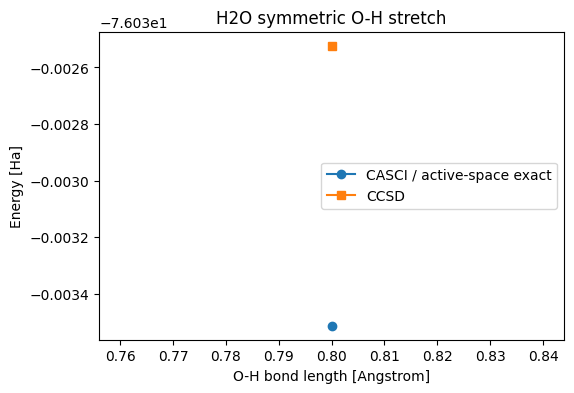

In [6]:
# 1i: plot the reference and CCSD stretch curves.

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    h2o_summary_df["R_OH [A]"],
    h2o_summary_df["CASCI energy [Ha]"],
    marker="o",
    label="CASCI / active-space exact",
)
ax.plot(
    h2o_summary_df["R_OH [A]"],
    h2o_summary_df["CCSD energy [Ha]"],
    marker="s",
    label="CCSD",
)
ax.set_xlabel("O-H bond length [Angstrom]")
ax.set_ylabel("Energy [Ha]")
ax.set_title("H2O symmetric O-H stretch")
ax.legend()
plt.show()

### Problem 2. Build and compare LUCJ ansatz circuits for heavy-hex and square connectivity

**Goal.** Build the same LUCJ ansatz under two different locality assumptions:

1. `heavy-hex`: sparse opposite-spin couplings, approximately `(0, 0), (4, 4), ...`.
2. `square`: a two-leg ladder with all opposite-spin rungs `(p, p)`.

This comparison is useful because the heavy-hex layout is closer to IBM hardware connectivity, while the square layout gives a more expressive local LUCJ ansatz. In this notebook, use the transpiled circuits to compare topology/depth, but use the logical ffsim circuits for ideal sample generation.


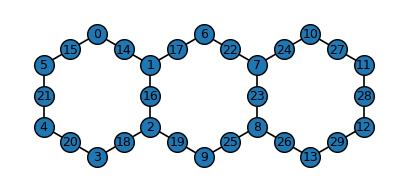

In [7]:
BASIS_GATES = ["cp", "xx_plus_yy", "p", "x", "swap"]

heavy_hex_coupling_map, heavy_hex_pos = make_heavy_hex_grid(rows=1, cols=3)
plot_coupling_map(heavy_hex_coupling_map, heavy_hex_pos)
heavy_hex_backend = GenericBackendV2(
    heavy_hex_coupling_map.size(),
    coupling_map=heavy_hex_coupling_map,
    basis_gates=BASIS_GATES,
)


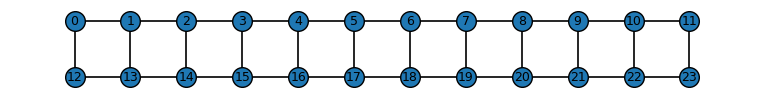

In [8]:
square_coupling_map, square_pos = make_square_grid(rows=2, cols=12)
plot_coupling_map(square_coupling_map, square_pos)
square_backend = GenericBackendV2(
    square_coupling_map.size(),
    coupling_map=square_coupling_map,
    basis_gates=BASIS_GATES,
)

In [9]:
selected_index = 0
selected_case = h2o_cases[selected_index]

# Global
n_orb = selected_case["norb"]
nelec = selected_case["nelec"]

connectivities_to_compare = ["heavy-hex", "square"]
backends = {
    "heavy-hex": heavy_hex_backend,
    "square": square_backend,
}

coupling_maps = {
    "heavy-hex": (heavy_hex_coupling_map, heavy_hex_pos),
    "square": (square_coupling_map, square_pos),
}

In [ ]:
def build_lucj_circuit_for_case(
    case: dict,
    connectivity: str,
    n_reps: int = 2,
    optimization_level: int = 3,
):
    """Build and transpile an LUCJ circuit for one H2O active-space case.

    The same function is used for both heavy-hex and square connectivity so that
    the resulting depths, accepted alpha-beta pairs, and sampled bitstrings are
    directly comparable.
    """
    t1 = case["t1"]
    t2 = case["t2"]

    if connectivity == "heavy-hex":
        aa_pairs = [(p, p+1) for p in range(0, n_orb-1)]
        ab_pairs = [(p, p) for p in range(0, n_orb, 4)]
    elif connectivity == "square":
        aa_pairs = [(p, p+1) for p in range(0, n_orb-1)]
        ab_pairs = [(p, p) for p in range(0, n_orb, 1)]
    else:
        raise ValueError(f"Unsupported connectivity: {connectivity}")

    pass_manager, ab_pairs = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backends[connectivity],
        norb=n_orb,
        connectivity=connectivity,
        interaction_pairs=(aa_pairs, ab_pairs),
        optimization_level=optimization_level,
    )

    # 2c: create the spin-balanced UCJ operator from CCSD amplitudes.
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(aa_pairs, ab_pairs),
        optimize=True,
        options=dict(maxiter=10),
    )

    # 2d: build the circuit.
    qubits = QuantumRegister(2 * n_orb, name="q")
    circuit = QuantumCircuit(qubits)
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(n_orb, nelec), qubits)
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    circuit.measure_all()

    # 2e: transpile the circuit with the LUCJ-specialized pass manager.
    isa_circuit = pass_manager.run(circuit)

    return {
        "circuit": circuit,
        "isa_circuit": isa_circuit,
        "pass_manager": pass_manager,
        "connectivity": connectivity,
        "aa_pairs": aa_pairs,
        "ab_pairs": ab_pairs,
        "n_reps": n_reps,
        "backend": backends[connectivity],
    }

In [11]:
lucj_data_by_connectivity = {}
backend_by_connectivity = {}
pos_by_connectivity = {}
coupling_map_by_connectivity = {}
summary_rows = []

for connectivity in connectivities_to_compare:
    backend_i = backends[connectivity]
    coupling_map_i, pos_i = coupling_maps[connectivity]

    lucj_data_i = build_lucj_circuit_for_case(
        selected_case,
        connectivity=connectivity,
        n_reps=2,
    )

    isa_circuit_i = lucj_data_i["isa_circuit"]

    backend_by_connectivity[connectivity] = backend_i
    pos_by_connectivity[connectivity] = pos_i
    coupling_map_by_connectivity[connectivity] = coupling_map_i
    lucj_data_by_connectivity[connectivity] = lucj_data_i

    summary_rows.append(
        {
            "connectivity": connectivity,
            "backend_qubits": coupling_map_i.size(),
            "logical_qubits": 2 * selected_case["norb"],
            "ab_pairs": len(lucj_data_i["aa_pairs"]),
            "ab_pair_list": lucj_data_i["ab_pairs"],
            "depth": isa_circuit_i.depth(),
            "size": isa_circuit_i.size(),
            "two_qubit_depth": isa_circuit_i.depth(filter_function=lambda inst: inst.operation.num_qubits == 2),
            "gate_counts": dict(isa_circuit_i.count_ops()),
        }
    )

lucj_summary_df = pd.DataFrame(summary_rows)
display(lucj_summary_df)

E0517 03:45:50.401313  219140 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0517 03:45:50.411661  218452 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


,connectivity,backend_qubits,logical_qubits,ab_pairs,ab_pair_list,depth,size,two_qubit_depth,gate_counts
0,heavy-hex,30,24,11,"[(0, 0), (4, 4), (8, 8)]",49,470,45,"{'xx_plus_yy': 328, 'cp': 50, 'p': 48, 'measur..."
1,square,24,24,11,"[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5...",45,476,41,"{'xx_plus_yy': 328, 'cp': 68, 'p': 48, 'measur..."



=== heavy-hex layout and alpha-beta paths ===


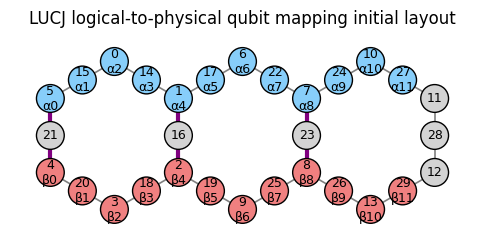

,ab_pair,alpha,beta,alpha_physical,beta_physical,distance,path
0,"(0, 0)",alpha_0,beta_0,5,4,2,"[5, 21, 4]"
1,"(4, 4)",alpha_4,beta_4,1,2,2,"[1, 16, 2]"
2,"(8, 8)",alpha_8,beta_8,7,8,2,"[7, 23, 8]"



=== square layout and alpha-beta paths ===


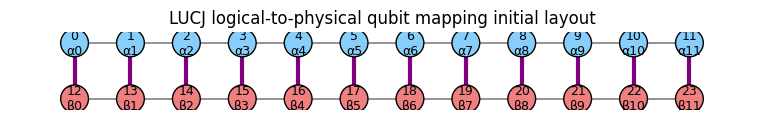

,ab_pair,alpha,beta,alpha_physical,beta_physical,distance,path
0,"(0, 0)",alpha_0,beta_0,0,12,1,"[0, 12]"
1,"(1, 1)",alpha_1,beta_1,1,13,1,"[1, 13]"
2,"(2, 2)",alpha_2,beta_2,2,14,1,"[2, 14]"
3,"(3, 3)",alpha_3,beta_3,3,15,1,"[3, 15]"
4,"(4, 4)",alpha_4,beta_4,4,16,1,"[4, 16]"
5,"(5, 5)",alpha_5,beta_5,5,17,1,"[5, 17]"
6,"(6, 6)",alpha_6,beta_6,6,18,1,"[6, 18]"
7,"(7, 7)",alpha_7,beta_7,7,19,1,"[7, 19]"
8,"(8, 8)",alpha_8,beta_8,8,20,1,"[8, 20]"
9,"(9, 9)",alpha_9,beta_9,9,21,1,"[9, 21]"


In [ ]:
for connectivity in connectivities_to_compare:
    print(f"\n=== {connectivity} layout and alpha-beta paths ===")
    logical_to_physical = plot_lucj_mapping_from_result(
        lucj_data_by_connectivity[connectivity],
        backend=backend_by_connectivity[connectivity],
        pos=pos_by_connectivity[connectivity],
        show_ab_paths=True,
    )

    ab_paths_df = lucj_ab_pair_paths_dataframe(
        lucj_data_by_connectivity[connectivity],
        backend=backend_by_connectivity[connectivity],
    )
    display(ab_paths_df)


### Problem 3. Sample bitstrings and compare sample diversity

**Goal.** Generate samples from the heavy-hex and square LUCJ circuits without constructing a full $2^{2n_{\mathrm{orb}}}$ statevector, then compare how the topology affects sample diversity.

Use `ffsim.qiskit.FfsimSampler` for this step. The sampler exploits the fermionic particle-number and spin-sector structure of the LUCJ circuit, so this is much lighter than using `StatevectorSampler` for the larger H₂O active spaces.

**What you should do**

1. Run `FfsimSampler` on each untranspiled logical LUCJ circuit.
2. Extract the resulting `bit_array` for each topology.
3. Check the number of unique bitstrings and the valid particle-number fraction.
4. Compare heavy-hex and square connectivity.

**Deliverables**

- A table with topology, allowed AB pairs, circuit depth, unique bitstrings, and valid fraction.
- A short explanation of why square connectivity can produce more diverse LUCJ samples.

**Practical note.** Use the transpiled `isa_circuit` for depth and hardware-topology analysis. For ideal SQD sample generation, use the logical ffsim circuit because `FfsimSampler` is specialized for fermionic gates and supported number-preserving Qiskit gates.


In [13]:
def is_valid_bitstring(bitstring: str, norb: int, nelec: tuple[int, int]) -> bool:
    """Return True if the bitstring has the correct alpha and beta electron counts.

    Refer to tutorial Step 4.
    """
    n_alpha, n_beta = nelec

    return (
        len(bitstring) == 2 * norb
        and bitstring[norb:].count("1") == n_alpha
        and bitstring[:norb].count("1") == n_beta
    )


def sample_lucj_circuit(
    circuit,
    shots: int,
    seed: int = 1234,
    global_depolarizing: float = 1e-2,
):
    """Sample an LUCJ circuit using ffsim's fermionic sampler.

    Pass either `case` or the explicit pair `(norb, nelec)`. For ideal SQD
    sampling, pass the untranspiled logical circuit, not the large ISA circuit.
    """

    sampler = ffsim.qiskit.FfsimSampler(
        default_shots=shots,
        norb=n_orb,
        nelec=nelec,
        global_depolarizing=global_depolarizing,
        seed=seed,
    )
    job = sampler.run([circuit], shots=shots)
    pub_result = job.result()[0]
    return pub_result.data.meas


In [29]:
shots = 100_000

bit_arrays_by_connectivity = {}
sampling_rows = []

norb = selected_case["norb"]
nelec = selected_case["nelec"]
n_alpha, n_beta = nelec

for connectivity in connectivities_to_compare:
    # Use the logical ffsim circuit for sample generation.
    # The transpiled ISA circuit is used above for depth and topology analysis.
    bit_array_i = sample_lucj_circuit(
        lucj_data_by_connectivity[connectivity]["circuit"],
        shots=shots,
        seed=1234,
    )
    counts_i = bit_array_i.get_counts()
    bit_arrays_by_connectivity[connectivity] = bit_array_i

    num_valid = sum(
        is_valid_bitstring(b, norb, nelec)
        for b in bit_array_i.get_bitstrings()
    )
    valid_fraction = num_valid / bit_array_i.num_shots

    sampling_rows.append(
        {
            "connectivity": connectivity,
            "shots": shots,
            "allowed_ab_pairs": len(lucj_data_by_connectivity[connectivity]["ab_pairs"]),
            "depth": lucj_data_by_connectivity[connectivity]["isa_circuit"].depth(),
            "unique_bitstrings": len(counts_i),
            "valid_fraction": valid_fraction,
            "top_bitstring_probability": max(counts_i.values()) / shots,
        }
    )

sampling_summary_df = pd.DataFrame(sampling_rows)
display(sampling_summary_df)

,connectivity,shots,allowed_ab_pairs,depth,unique_bitstrings,valid_fraction,top_bitstring_probability
0,heavy-hex,100000,3,49,1174,0.98935,0.97671
1,square,100000,12,45,1204,0.98935,0.97282


### Problem 4. Run SQD for both LUCJ layouts at one H₂O stretch geometry

**Goal.** Use the heavy-hex and square samples from Problem 3 to run SQD under the same post-processing settings, then compare the final energies directly.

This is the fast single-geometry energy comparison. Problem 5 repeats the same idea over a small stretch grid.

**What you should do**

1. Reuse `bit_arrays_by_connectivity` from Problem 3.
2. Run `run_sqd_for_case` once for each topology.
3. Store the final SQD energy, energy error, sample diversity, accepted AB pairs, and circuit depth in a table.
4. Compare the convergence curves and final orbital occupancies.

**Practical note.** The two SQD runs use the same Hamiltonian and the same SQD settings. The only difference is the LUCJ sample distribution generated by the two layouts.


In [48]:
NUM_BATCHES = 1
SAMPLES_PER_BATCH = 500
ENERGY_TOL = 1e-5
OCCUPANCIES_TOL = 1e-5
MAX_ITERATIONS = 5
MAX_CYCLE = 200
CARRYOVER_THRESHOLD = 1e-6


def run_sqd_for_case(
    case: dict,
    bit_array,
    seed: int = 1234,
):
    """Run SQD for one active-space Hamiltonian and one set of bitstring samples."""
    hcore, eri = case["hcore"], case["eri"]
    nuclear_repulsion_energy = case["nuclear_repulsion_energy"]

    # 4a: construct the Hartree-Fock initial occupancy arrays.
    initial_occupancies = (
        np.array([1] * n_alpha + [0] * (norb - n_alpha)),
        np.array([1] * n_beta + [0] * (norb - n_beta)),
    )

    # 4b: create the SCI solver.
    sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=MAX_CYCLE)

    result_history = []

    def callback(results: list[SCIResult]):
        result_history.append(results)
        iteration = len(result_history)
        print(f"Iteration {iteration}")
        for i, result in enumerate(results):
            print(f"  batch {i}")
            print(f"    Energy: {result.energy + nuclear_repulsion_energy:.10f} Ha")
            print(f"    Subspace dimension: {np.prod(result.sci_state.amplitudes.shape)}")

    # 4c: call diagonalize_fermionic_hamiltonian.
    rng = np.random.default_rng(seed)
    result = diagonalize_fermionic_hamiltonian(
        hcore,
        eri,
        bit_array,
        samples_per_batch=SAMPLES_PER_BATCH,
        norb=norb,
        nelec=nelec,
        num_batches=NUM_BATCHES,
        energy_tol=ENERGY_TOL,
        occupancies_tol=OCCUPANCIES_TOL,
        max_iterations=MAX_ITERATIONS,
        sci_solver=sci_solver,
        symmetrize_spin=True,
        initial_occupancies=initial_occupancies,
        carryover_threshold=CARRYOVER_THRESHOLD,
        callback=callback,
        seed=rng,
    )

    final_energy = result.energy + nuclear_repulsion_energy
    energy_error = final_energy - case["reference_energy"]
    return result, result_history, final_energy, energy_error

In [49]:
def run_sqd_layout_comparison(
    case: dict,
    bit_arrays_by_connectivity: dict,
    seed: int = 1234,
):
    """Run SQD for each layout and return an energy-comparison table."""

    rows = []
    results_by_connectivity = {}
    histories_by_connectivity = {}

    for connectivity in connectivities_to_compare:
        print(f"\n=== SQD for {connectivity} samples ===")
        bit_array_i = bit_arrays_by_connectivity[connectivity]
        counts_i = bit_array_i.get_counts()

        result_i, history_i, final_energy_i, energy_error_i =\
            run_sqd_for_case(case, bit_array_i, seed=seed)

        results_by_connectivity[connectivity] = result_i
        histories_by_connectivity[connectivity] = history_i
        lucj_data_i = lucj_data_by_connectivity[connectivity]
        isa_circuit_i = lucj_data_i["isa_circuit"]
        two_qubit_depth = isa_circuit_i.depth(
            filter_function=lambda inst: inst.operation.num_qubits == 2
        )

        rows.append(
            {
                "connectivity": connectivity,
                "R_OH [A]": case["r_oh"],
                "reference_energy [Ha]": case["reference_energy"],
                "sqd_energy [Ha]": final_energy_i,
                "sqd_error [mHa]": 1000.0 * energy_error_i,
                "unique_bitstrings": len(counts_i),
                "top_bitstring_probability": max(counts_i.values()) / bit_array_i.num_shots,
                "num_ab_pairs": len(lucj_data_i["ab_pairs"]),
                "ab_pairs": lucj_data_i["ab_pairs"],
                "depth": isa_circuit_i.depth(),
                "two_qubit_depth": two_qubit_depth,
            }
        )

    energy_df = pd.DataFrame(rows).sort_values("connectivity").reset_index(drop=True)
    return energy_df, results_by_connectivity, histories_by_connectivity


sqd_layout_energy_df, sqd_results_by_connectivity, sqd_histories_by_connectivity = (
    run_sqd_layout_comparison(
        selected_case,
        bit_arrays_by_connectivity,
        seed=1234,
    )
)

print("\n=== Heavy-hex vs square SQD energy comparison ===")
display(
    sqd_layout_energy_df[[
        "connectivity",
        "R_OH [A]",
        "reference_energy [Ha]",
        "sqd_energy [Ha]",
        "sqd_error [mHa]",
        "unique_bitstrings",
        "top_bitstring_probability",
        "num_ab_pairs",
        "depth",
        "two_qubit_depth",
    ]]
)



=== SQD for heavy-hex samples ===
Iteration 1
  batch 0
    Energy: -76.0324300713 Ha
    Subspace dimension: 108241
Iteration 2
  batch 0
    Energy: -76.0333896124 Ha
    Subspace dimension: 175561
Iteration 3
  batch 0
    Energy: -76.0334217264 Ha
    Subspace dimension: 202500
Iteration 4
  batch 0
    Energy: -76.0334560411 Ha
    Subspace dimension: 216225
Iteration 5
  batch 0
    Energy: -76.0334568588 Ha
    Subspace dimension: 224676

=== SQD for square samples ===
Iteration 1
  batch 0
    Energy: -76.0326850224 Ha
    Subspace dimension: 103041
Iteration 2
  batch 0
    Energy: -76.0333463600 Ha
    Subspace dimension: 166464
Iteration 3
  batch 0
    Energy: -76.0334059628 Ha
    Subspace dimension: 195364
Iteration 4
  batch 0
    Energy: -76.0334907378 Ha
    Subspace dimension: 207936
Iteration 5
  batch 0
    Energy: -76.0334915985 Ha
    Subspace dimension: 218089

=== Heavy-hex vs square SQD energy comparison ===


,connectivity,R_OH [A],reference_energy [Ha],sqd_energy [Ha],sqd_error [mHa],unique_bitstrings,top_bitstring_probability,num_ab_pairs,depth,two_qubit_depth
0,heavy-hex,0.8,-76.033512,-76.033457,0.055366,1174,0.97671,3,49,45
1,square,0.8,-76.033512,-76.033492,0.020626,1204,0.97282,12,45,41


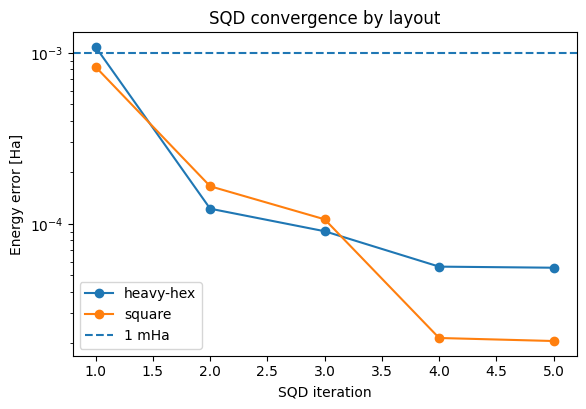

,heavy-hex,square
spatial_orbital,,
0,1.988327,1.988306
1,1.978599,1.978609
2,1.981039,1.981020
3,1.981943,1.981912
4,0.005731,0.005757
5,0.007590,0.007581
6,0.003166,0.003165
7,0.016995,0.017026
8,0.012779,0.012800


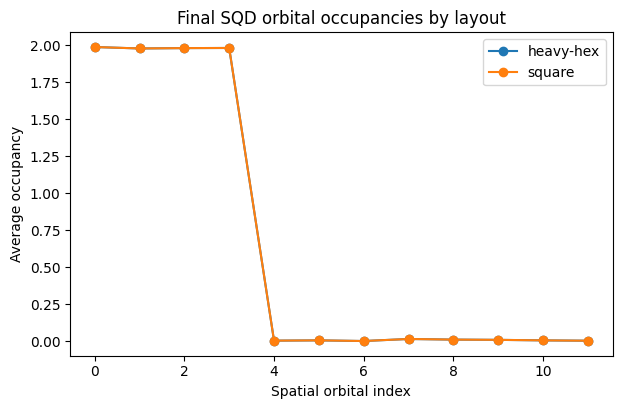

In [50]:
# 4d: visualize SQD convergence, final energy error, and final occupancies for both layouts.

fig, ax = plt.subplots(figsize=(6.5, 4.2))

for connectivity, history in sqd_histories_by_connectivity.items():
    min_energy_by_iteration = [
        min(batch_results, key=lambda res: res.energy).energy
        + selected_case["nuclear_repulsion_energy"]
        for batch_results in history
    ]
    energy_errors = [
        abs(energy - selected_case["reference_energy"])
        for energy in min_energy_by_iteration
    ]
    ax.plot(
        range(1, len(energy_errors) + 1),
        energy_errors,
        marker="o",
        label=connectivity,
    )

ax.axhline(0.001, linestyle="--", label="1 mHa")
ax.set_yscale("log")
ax.set_xlabel("SQD iteration")
ax.set_ylabel("Energy error [Ha]")
ax.set_title("SQD convergence by layout")
ax.legend()
plt.show()

occupancy_df = pd.DataFrame(
    {
        connectivity: np.sum(result.orbital_occupancies, axis=0)
        for connectivity, result in sqd_results_by_connectivity.items()
    }
)
occupancy_df.index.name = "spatial_orbital"
display(occupancy_df)

fig, ax = plt.subplots(figsize=(7, 4.2))
for connectivity in occupancy_df.columns:
    ax.plot(
        occupancy_df.index,
        occupancy_df[connectivity],
        marker="o",
        label=connectivity,
    )
ax.set_xlabel("Spatial orbital index")
ax.set_ylabel("Average occupancy")
ax.set_title("Final SQD orbital occupancies by layout")
ax.legend()
plt.show()


### Problem 5. Build a small SQD potential-energy comparison for H₂O stretch

**Goal.** Combine Problems 1–4 into a small end-to-end SQD PES workflow and compare heavy-hex against square connectivity.

This is the main challenge problem. Keep the grid small during the workshop.

**What you should do**

1. For each selected O–H distance and each topology:
   - build the active-space Hamiltonian,
   - build the LUCJ circuit,
   - sample bitstrings,
   - run SQD.
2. Store the results in a DataFrame.
3. Plot the active-space reference PES and the SQD PES for both topologies.
4. Compare depth, allowed AB pairs, unique bitstrings, and SQD error.

**Deliverables**

- A table with `R_OH`, topology, reference energy, CCSD energy, SQD energy, SQD error, circuit depth, allowed AB pairs, and unique bitstrings.
- A PES plot comparing reference, CCSD, heavy-hex SQD, and square SQD energies.
- A short written discussion.

**Practical note.** If this becomes slow, use only one or two points first, or reduce `shots` to `5_000`.
